# Data Preparation — Churn Prediction
**Universidad Alfonso X el Sabio (UAX)**


En esta fase preparamos los datos para el modelado. El objetivo es transformar el dataset crudo en un conjunto limpio, numérico y listo para alimentar algoritmos de Machine Learning. Seguimos el orden: **split → transformación → verificación → guardado**.


## 1. Librerías y configuración visual


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Paleta corporativa UAX ──────────────────────────────────
UAX_NAVY    = '#1B2A4A'
UAX_GOLD    = '#C8A951'
UAX_LIGHT   = '#E8E0D0'
UAX_GREY    = '#6B7B8D'
UAX_ACCENT  = '#3A5BA0'

uax_palette = [UAX_NAVY, UAX_GOLD, UAX_ACCENT, UAX_GREY]

# ── Estilo global ───────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.edgecolor':   UAX_GREY,
    'axes.labelcolor':  UAX_NAVY,
    'text.color':       UAX_NAVY,
    'xtick.color':      UAX_GREY,
    'ytick.color':      UAX_GREY,
    'grid.color':       '#E0E0E0',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  UAX_GREY,
})
sns.set_style('white')
print('✓ Configuración visual UAX cargada')


✓ Configuración visual UAX cargada


## 2. Carga de datos y conversión de fechas


In [2]:
customer_data = pd.read_csv('data/lake/customer_data.csv')

# Convertir columnas de fecha
customer_data[['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']] = (
    customer_data[['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']]
        .apply(pd.to_datetime, errors='coerce', dayfirst=True, format='%d/%m/%Y')
)

print(f'Dataset cargado: {customer_data.shape[0]:,} filas × {customer_data.shape[1]} columnas')


Dataset cargado: 58,049 filas × 40 columnas


## 3. División Train / Test


Separamos **antes** de transformar para evitar *data leakage*: que información del test contamine el entrenamiento. Usamos 80/20.


In [3]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(customer_data, test_size=0.2, random_state=42)

print(f'Train: {train_set.shape[0]:,} filas ({train_set.shape[0]/len(customer_data)*100:.0f}%)')
print(f'Test:  {test_set.shape[0]:,} filas ({test_set.shape[0]/len(customer_data)*100:.0f}%)')


Train: 46,439 filas (80%)
Test:  11,610 filas (20%)


Verificamos que la proporción de churn se mantiene en ambos conjuntos (el split estratificado no es estrictamente necesario aquí, pero comprobémoslo).


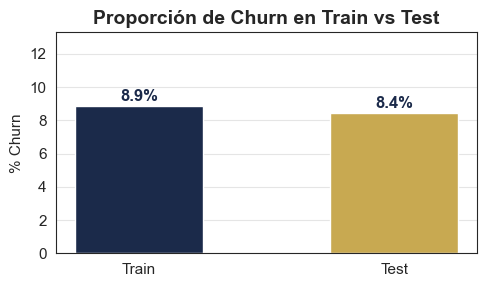

In [4]:
churn_train = (train_set['Churn_400'] == 'Y').mean() * 100
churn_test  = (test_set['Churn_400'] == 'Y').mean() * 100

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(['Train', 'Test'], [churn_train, churn_test],
              color=[UAX_NAVY, UAX_GOLD], edgecolor='white', width=0.5)
ax.set_ylabel('% Churn')
ax.set_title('Proporción de Churn en Train vs Test')
ax.set_ylim(0, max(churn_train, churn_test) * 1.5)
ax.grid(axis='y')

for bar, val in zip(bars, [churn_train, churn_test]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold', color=UAX_NAVY)

plt.tight_layout()
plt.show()


Las proporciones son prácticamente iguales. El split aleatorio ha mantenido la distribución del target, lo cual es bueno.


## 4. Guardar Test set (intacto)


El test set se guarda tal cual, sin transformar. Lo transformaremos más adelante usando el mismo pipeline entrenado con el train.


In [5]:
test_set.to_csv('data/warehouse/test_set.csv', index=False)
print(f'Test set guardado → data/warehouse/test_set.csv ({test_set.shape[0]:,} filas)')


Test set guardado → data/warehouse/test_set.csv (11,610 filas)


## 5. Pipeline de transformación


Aplicamos un pipeline secuencial con transformadores custom (definidos en `transformer.py`). Cada paso tiene una responsabilidad clara:

| Paso | Transformador | Qué hace |
|---|---|---|
| 1 | `BinaryEncoder` | Variables SI/NO → 0/1 |
| 2 | `FrequencyEncoder` | Variables de alta cardinalidad → frecuencia relativa |
| 3 | `OrdinalExtensionEncoder` | Extensión de garantía → escala ordinal |
| 4 | `OrdinalEquipamientoEncoder` | Nivel de equipamiento → escala ordinal |
| 5 | `NominalOneHotEncoder` | Categóricas nominales → one-hot encoding |
| 6 | `PriceStandard` | Estandarización de variables de precio |
| 7 | `InstanceDropper` | Elimina filas con nulos o incoherencias |
| 8 | `ColumnDropper` | Descarta columnas que no aportan al modelo |


In [6]:
from transformer import (BinaryEncoder, FrequencyEncoder, OrdinalExtensionEncoder,
                         OrdinalEquipamientoEncoder, NominalOneHotEncoder,
                         PriceStandard, InstanceDropper, ColumnDropper)
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ('binary',           BinaryEncoder()),
    ('frequency',        FrequencyEncoder()),
    ('ordinal_ext',      OrdinalExtensionEncoder()),
    ('ordinal_equip',    OrdinalEquipamientoEncoder()),
    ('onehot',           NominalOneHotEncoder()),
    ('price_standard',   PriceStandard()),
    ('instance_dropper', InstanceDropper()),
    ('dropper',          ColumnDropper()),
])

print('✓ Pipeline definido con', len(full_pipeline.steps), 'pasos')


✓ Pipeline definido con 8 pasos


## 6. Aplicar pipeline al Train set


In [7]:
train_set_prepared = full_pipeline.fit_transform(train_set)

print(f'Antes:   {train_set.shape[0]:,} filas × {train_set.shape[1]} columnas')
print(f'Después: {train_set_prepared.shape[0]:,} filas × {train_set_prepared.shape[1]} columnas')
print(f'Filas eliminadas: {train_set.shape[0] - train_set_prepared.shape[0]:,}')


Antes:   46,439 filas × 40 columnas
Después: 35,982 filas × 36 columnas
Filas eliminadas: 10,457


El pipeline ha reducido filas (por el `InstanceDropper`) y ha transformado las columnas originales en un conjunto numérico listo para el modelo.


## 7. Verificación del resultado


### 7.1 Tipos de datos


In [8]:
print(train_set_prepared.dtypes.value_counts().to_string())
print(f'\nNulos restantes: {train_set_prepared.isnull().sum().sum()}')


float64    26
int64      10

Nulos restantes: 0


### 7.2 Distribuciones del dataset transformado


Visualizamos las distribuciones para comprobar que las transformaciones tienen sentido y no hay anomalías.


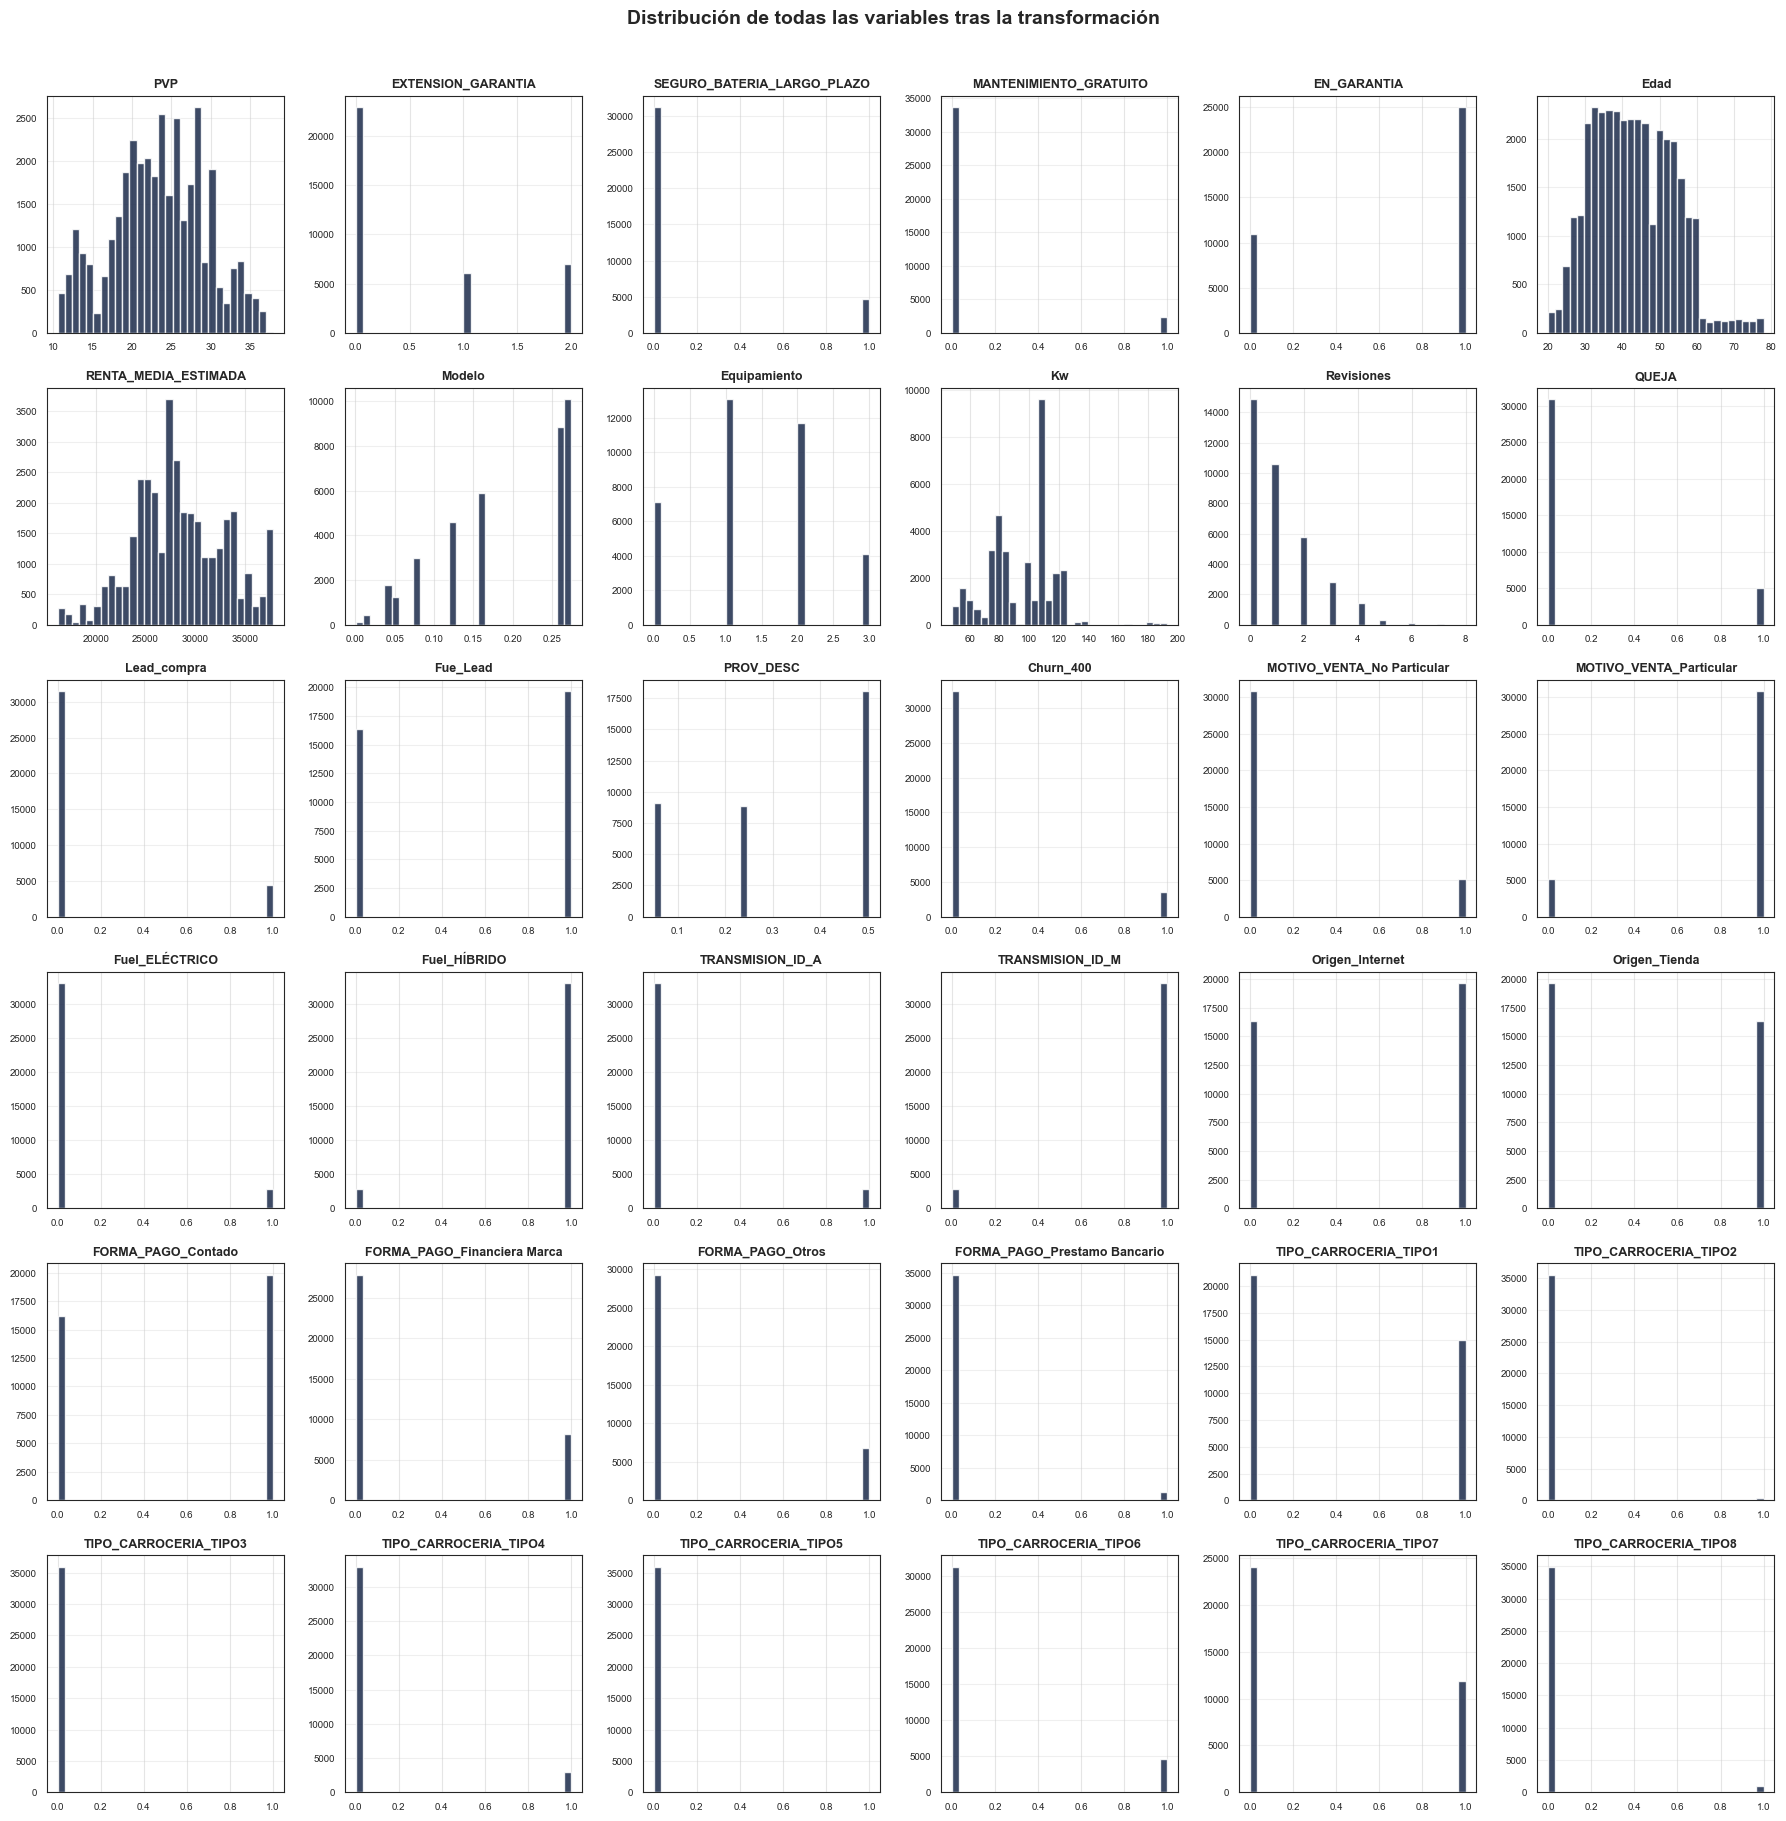

In [9]:
cols = train_set_prepared.columns.tolist()
n_cols_plot = 6
n_rows_plot = -(-len(cols) // n_cols_plot)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 3 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    train_set_prepared[col].hist(bins=30, ax=ax, color=UAX_NAVY, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de todas las variables tras la transformación',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Puntos a observar:

- Las variables **one-hot** (binarias) muestran dos barras en 0 y 1 — es lo esperado.
- **PVP** y **MANTENIMIENTO_GRATUITO** deberían estar estandarizadas gracias al `PriceStandard`.
- Las variables de frecuencia (`Modelo`, `PROV_DESC`) muestran distribuciones continuas entre 0 y 1.
- **No hay nulos** tras el pipeline.


### 7.3 Balance del target tras la transformación


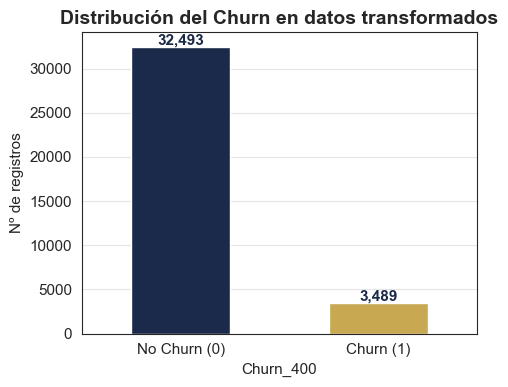

Ratio Churn: 0.11 (1:9)


In [10]:
churn_prepared = train_set_prepared['Churn_400'].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
churn_prepared.plot(kind='bar', color=[UAX_NAVY, UAX_GOLD], edgecolor='white', ax=ax)
ax.set_title('Distribución del Churn en datos transformados')
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
ax.set_ylabel('Nº de registros')
ax.grid(axis='y')

for i, (idx, val) in enumerate(churn_prepared.items()):
    ax.text(i, val + 200, f'{val:,}', ha='center', fontsize=11, fontweight='bold', color=UAX_NAVY)

plt.tight_layout()
plt.show()

print(f'Ratio Churn: {churn_prepared.min() / churn_prepared.max():.2f} (1:{churn_prepared.max()//churn_prepared.min()})')


El desbalance se mantiene. Será necesario aplicar alguna técnica de balanceo (SMOTE, undersampling, o ajuste de `class_weight`) en la fase de modelado.


### 7.4 Correlación con el target


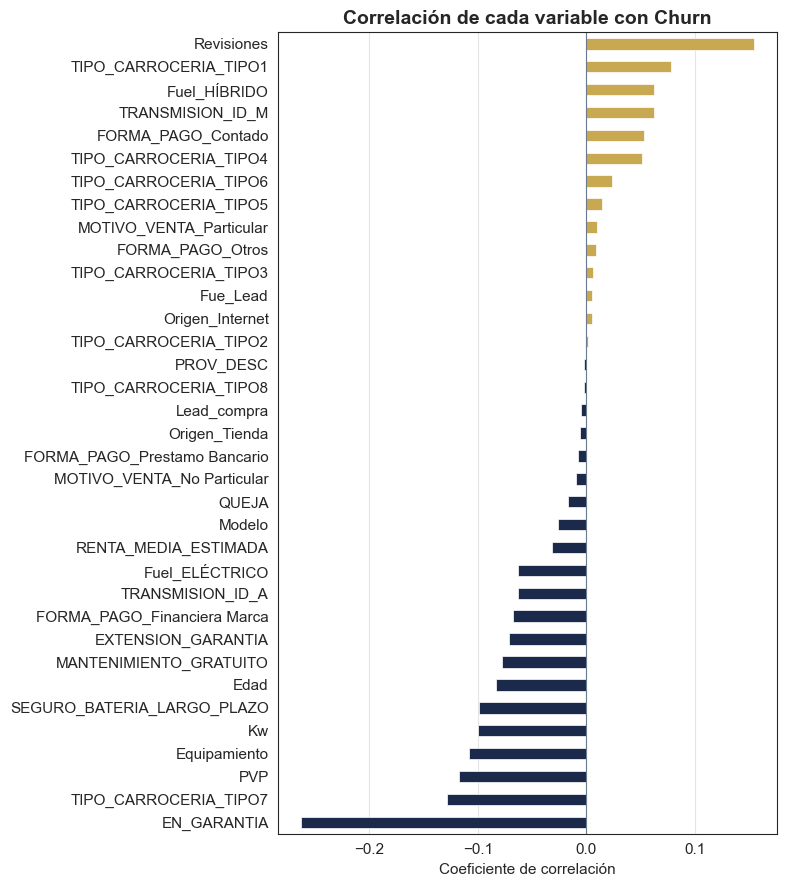

In [11]:
corr_target = train_set_prepared.corr()['Churn_400'].drop('Churn_400').sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = [UAX_GOLD if v > 0 else UAX_NAVY for v in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Correlación de cada variable con Churn')
ax.set_xlabel('Coeficiente de correlación')
ax.axvline(x=0, color=UAX_GREY, linewidth=0.8)
ax.grid(axis='x')
plt.tight_layout()
plt.show()


Las variables con **mayor correlación positiva** con el churn (las que más "empujan" al abandono) y las de **correlación negativa** (las que retienen al cliente) nos dan una vista rápida de qué features serán más útiles para el modelo.

Esto confirma lo que observamos en la fase de exploración: la garantía, las revisiones y la forma de pago son factores determinantes.


## 8. Separar features / target y guardar


In [12]:
import joblib

X_train_prepared = train_set_prepared.drop(columns=['Churn_400'])
y_train = train_set_prepared['Churn_400']

print(f'X_train: {X_train_prepared.shape}')
print(f'y_train: {y_train.shape} — distribución: {dict(y_train.value_counts())}')


X_train: (35982, 35)
y_train: (35982,) — distribución: {0: np.int64(32493), 1: np.int64(3489)}


In [13]:
joblib.dump(full_pipeline, 'data/warehouse/num_pipeline.pkl')
joblib.dump(X_train_prepared, 'data/warehouse/X_train_prepared.pkl')
joblib.dump(y_train, 'data/warehouse/y_train.pkl')

print('✓ Artefactos guardados en data/warehouse/')
print('  → num_pipeline.pkl')
print('  → X_train_prepared.pkl')
print('  → y_train.pkl')


✓ Artefactos guardados en data/warehouse/
  → num_pipeline.pkl
  → X_train_prepared.pkl
  → y_train.pkl


## 9. Resumen


| Concepto | Valor |
|---|---|
| Filas originales (train) | ~46,400 |
| Filas tras pipeline | ~36,000 |
| Columnas finales | 36 (35 features + 1 target) |
| Nulos | 0 |
| Target | `Churn_400` (0 = No Churn, 1 = Churn) |
| Desbalance | ~1:9 — habrá que gestionarlo en modelado |
| Artefactos guardados | pipeline `.pkl`, `X_train`, `y_train` |

El dataset está listo para la fase de modelado.
